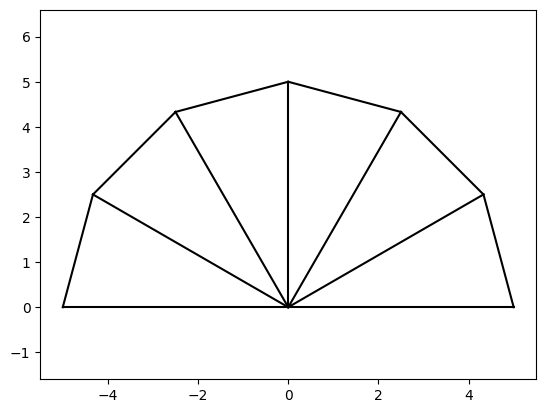

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Definições iniciais
bars = []
connects = []

r = 5
alpha = 30

# Montar os nós
connects.append((0,0))
for theta in range(180, -1, -alpha):
    
    theta_rad = math.radians(theta)
    x = math.cos(theta_rad)*r
    y = math.sin(theta_rad)*r

    connects.append((x, y))

# Montar as arestas
for i in range(1, len(connects)):
    bars.append((0, i, r))

dist = 2*r*math.sin(math.radians(alpha/2))
for i in range(1, len(connects)-1):
    bars.append((i, i+1, dist))


for b in bars:
    n1, n2, _ = b

    x1, y1 = connects[n1]
    x2, y2 = connects[n2]

    plt.plot([x1,x2],[y1,y2],'k')

plt.axis('equal')
plt.show()


In [5]:
def Rigidez(x1, y1, x2, y2, h, EA = 2*10**7):
    lx = (x2 - x1)/h
    ly = (y2 - y1)/h

    K = EA/h * np.array([[lx*lx, lx*ly, -lx*lx, -lx*ly],
                         [lx*ly, ly*ly, -lx*ly, -ly*ly],
                         [-lx*lx, -lx*ly, lx*lx, lx*ly],
                         [-lx*ly, -ly*ly, lx*ly, ly*ly]])
    
    return K


def KTotal(Kvector, bars, connects):
    n = len(connects)
    Ktot = np.zeros((2*n, 2*n))
    
    for b in range(len(bars)):
        k = Kvector[b]
        no1, no2, _ = bars[b]
        
        graus_lib = [2*no1, 2*no1 + 1, 2*no2, 2*no2 + 1]
        
        for i_Ke in range(len(k)):
            for j_Ke in range(len(k)):
                Ktot[graus_lib[i_Ke]][graus_lib[j_Ke]] += k[i_Ke][j_Ke]
                
    return(Ktot)

In [6]:
Kvector = []
for no1, no2, h in bars:
    x1, y1 = connects[no1]
    x2, y2 = connects[no2]

    Kvector.append(
        Rigidez(x1, y1, x2, y2, h)
    )


Ktot = KTotal(Kvector, bars, connects)

In [ ]:
print("Nós =", len(connects))
print("Barras =", len(bars))
print("Matrizes locais =", Kvector)
print("K global =", Ktot)

Nós = 8
Barras = 13
Matrizes locais = 13
K global = (16, 16)
